# Prediksi PM2.5 — ANN vs PSO-ANN
**Stasiun:** Bundaran HI  
**Validasi:** Cross-Validation Expanding Window  
**Peubah Input**: `PM10`, `SO₂`  `Lag1-7`
**Target:** `PM2.5`

# 1. Install & Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, backend as K

print('TensorFlow:', tf.__version__)
print('Library siap ✅')

TensorFlow: 2.20.0
Library siap ✅


# 2. Load Dataset

In [ ]:
from google.colab import files
print('Upload DATA_BUNDARAN_HI.xlsx')
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = pd.read_excel(filename)
print(f'Dataset: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom')
df_raw.head()

Upload DATA_BUNDARAN_HI.xlsx


Saving DATA BUNDARAN HI.xlsx to DATA BUNDARAN HI.xlsx
Dataset: 700 baris, 13 kolom


,periode_data,bulan,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori
0,202401,1,1,DKI1 BUNDARAN HI,64.0,89.0,52.0,9.0,13.0,30.0,89.0,PM25,SEDANG
1,202401,1,2,DKI1 BUNDARAN HI,53.0,93.0,52.0,4.0,12.0,28.0,93.0,PM25,SEDANG
2,202401,1,3,DKI1 BUNDARAN HI,52.0,57.0,52.0,6.0,12.0,27.0,57.0,PM25,SEDANG
3,202401,1,4,DKI1 BUNDARAN HI,30.0,NaN,112.0,20.0,8.0,77.0,112.0,SO2,TIDAK SEHAT
4,202401,1,5,DKI1 BUNDARAN HI,22.0,54.0,46.0,15.0,24.0,44.0,54.0,PM25,SEDANG


In [ ]:
df_raw['date'] = pd.to_datetime(
    df_raw['periode_data'].astype(str) + df_raw['tanggal'].astype(str).str.zfill(2),
    format='%Y%m%d'
)

# cek hasil
print(df_raw[['periode_data', 'tanggal', 'date']].head())

   periode_data  tanggal       date
0        202401        1 2024-01-01
1        202401        2 2024-01-02
2        202401        3 2024-01-03
3        202401        4 2024-01-04
4        202401        5 2024-01-05


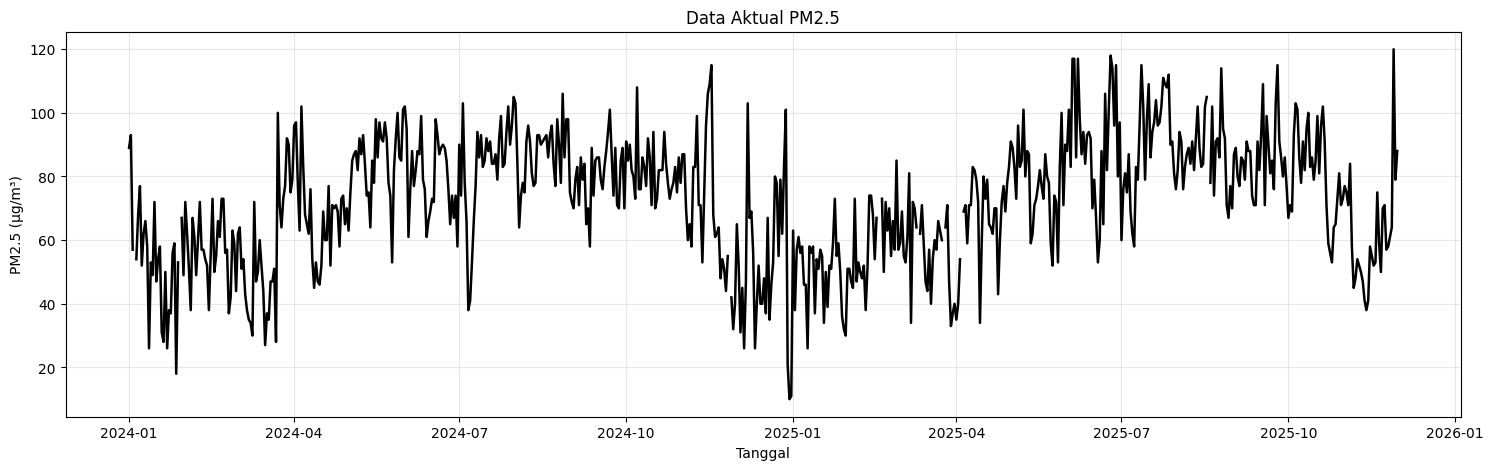

In [ ]:
plt.figure(figsize=(18,5))

plt.plot(
    df_raw['date'],
    df_raw['pm_duakomalima'],
    color='black',
    lw=1.8
)

plt.xlabel('Tanggal')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Data Aktual PM2.5')
plt.grid(alpha=0.3)

plt.show()

# 3. Preprocessing

## Cek Missing Value

In [ ]:
print(df_raw.isnull().sum())

periode_data                 0
bulan                        0
tanggal                      0
stasiun                      0
pm_sepuluh                   2
pm_duakomalima               9
sulfur_dioksida              7
karbon_monoksida             9
ozon                         7
nitrogen_dioksida            4
max                          1
parameter_pencemar_kritis    1
kategori                     0
date                         0
dtype: int64


## Interpolasi Linear

In [ ]:
kolom_imputasi = [
    'pm_sepuluh',
    'pm_duakomalima',
    'karbon_monoksida',
    'nitrogen_dioksida',
    'sulfur_dioksida'
]

df_raw[kolom_imputasi] = df_raw[kolom_imputasi].interpolate(method='linear')

# CEK ULANG MISSING VALUE
print(df_raw[kolom_imputasi].isnull().sum())

pm_sepuluh           0
pm_duakomalima       0
karbon_monoksida     0
nitrogen_dioksida    0
sulfur_dioksida      0
dtype: int64


In [ ]:
# Kolom numerik
all_features = ['pm_sepuluh', 'sulfur_dioksida', 'karbon_monoksida',
                'ozon', 'nitrogen_dioksida', 'pm_duakomalima']
rename_map = {
    'pm_sepuluh'       : 'PM10',
    'sulfur_dioksida'  : 'SO2',
    'karbon_monoksida' : 'CO',
    'ozon'             : 'O3',
    'nitrogen_dioksida': 'NO2',
    'pm_duakomalima'   : 'PM2.5'
}

print('\nStatistik Deskriptif:')
df_raw.describe().round(2)


Statistik Deskriptif:


,periode_data,bulan,tanggal,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,date
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00,693.00,700.00,699.00,700
mean,202453.99,6.28,15.73,48.25,72.26,26.03,18.36,19.00,34.04,73.04,2024-12-15 11:59:59.999999744
min,202401.00,1.00,1.00,14.00,10.00,6.00,3.00,2.00,8.00,26.00,2024-01-01 00:00:00
25%,202406.00,3.00,8.00,39.00,58.00,14.00,13.00,12.00,27.00,59.00,2024-06-23 18:00:00
50%,202412.00,6.00,16.00,52.00,73.50,27.00,18.00,18.00,35.00,74.00,2024-12-15 12:00:00
75%,202506.00,9.00,23.00,58.00,87.00,33.00,24.00,24.00,41.00,87.00,2025-06-08 06:00:00
max,202511.00,12.00,31.00,76.00,120.00,112.00,38.00,75.00,98.00,120.00,2025-11-30 00:00:00
std,49.85,3.32,8.80,13.27,19.72,13.76,7.06,8.31,10.33,18.77,NaN


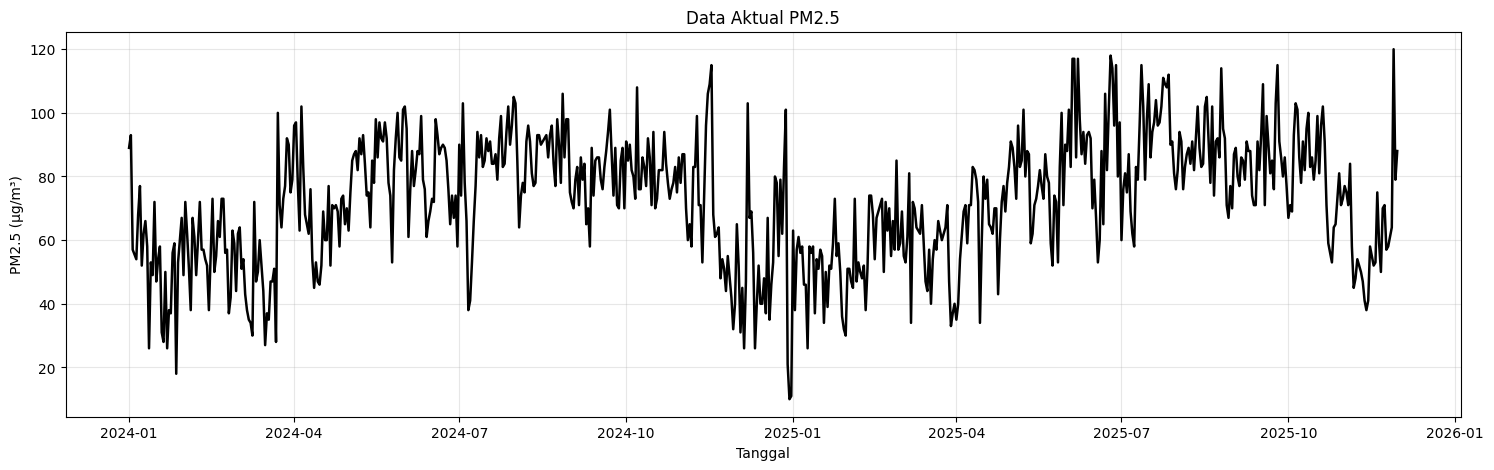

In [ ]:
plt.figure(figsize=(18,5))

plt.plot(
    df_raw['date'],
    df_raw['pm_duakomalima'],
    color='black',
    lw=1.8
)

plt.xlabel('Tanggal')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Data Aktual PM2.5')
plt.grid(alpha=0.3)

plt.show()

## Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Create a temporary DataFrame with renamed columns for feature importance calculation
# This ensures df_raw is not permanently modified for other parts of the notebook
df_temp = df_raw.rename(columns=rename_map)

# fitur input
X = df_temp[['PM10', 'SO2', 'CO', 'O3', 'NO2']]
y = df_temp['PM2.5']

# model RF
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

# importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

  Feature  Importance
0    PM10    0.829651
1     SO2    0.061691
2      CO    0.039232
4     NO2    0.036963
3      O3    0.032463


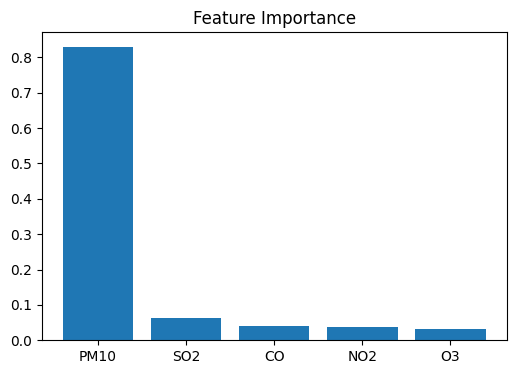

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(importance['Feature'], importance['Importance'])
plt.title('Feature Importance')
plt.show()

# Pengujian Kombinasi Prediktor

## PM10, SO2, CO

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'karbon_monoksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
     'karbon_monoksida' : 'CO',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2', 'CO']

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
CO         0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
CO         0
PM25       0
dtype: int64

Peubah input (M=3): ['PM10', 'SO2', 'CO']
Target output: PM25


In [ ]:
print('Missing values in final DataFrame:')
print(df.isnull().sum())

Missing values in final DataFrame:
Tanggal    0
PM10       0
SO2        0
CO         0
PM25       0
dtype: int64


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 3 → 7 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 700
  Min training set = 420 (60%)
  Step per fold    = 56
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:420] (420 data) | Test[420:476] (56 data)
  Fold 2: Train[0:476] (476 data) | Test[476:532] (56 data)
  Fold 3: Train[0:532] (532 data) | Test[532:588] (56 data)
  Fold 4: Train[0:588] (588 data) | Test[588:644] (56 data)
  Fold 5: Train[0:644] (644 data) | Test[644:700] (56 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:420] (420 data)
   Test : [420:476] (56 data)
   RMSE=7.1175  MAE=5.8168  MAPE=9.93%  R²=0.7138

── Fold 2/5 ──
   Train: [0:476] (476 data)
   Test : [476:532] (56 data)


   RMSE=13.0357  MAE=11.0558  MAPE=13.22%  R²=0.2717

── Fold 3/5 ──
   Train: [0:532] (532 data)
   Test : [532:588] (56 data)


   RMSE=13.3530  MAE=11.7997  MAPE=13.35%  R²=0.2901

── Fold 4/5 ──
   Train: [0:588] (588 data)
   Test : [588:644] (56 data)
   RMSE=11.7250  MAE=9.8297  MAPE=11.59%  R²=0.0057

── Fold 5/5 ──
   Train: [0:644] (644 data)
   Test : [644:700] (56 data)
   RMSE=13.4325  MAE=10.7963  MAPE=16.50%  R²=0.4573

  RATA-RATA CV ANN
  RMSE : 11.7328 ± 2.3880 µg/m³
  MAE  : 9.8597 ± 2.1174 µg/m³
  MAPE : 12.9193 ± 2.1801 %
  R2   : 0.3477 ± 0.2333


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 36


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:420]  Test: [420:476]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.006090
     iter  20/50 | best MSE = 0.004614
     iter  30/50 | best MSE = 0.004510
     iter  40/50 | best MSE = 0.004358
     iter  50/50 | best MSE = 0.004257
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=7.5798  MAE=5.7467  MAPE=10.01%  R²=0.6754

── Fold 2/5 ──
   Train: [0:476]  Test: [476:532]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.005180
     iter  20/50 | best MSE = 0.004832
     iter  30/50 | best MSE = 0.004656
     iter  40/50 | best MSE = 0.004516
     iter  50/50 | best MSE = 0.004447
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=9.1512  MAE=6.8964  MAPE=8.47%  R²=0.6411

── Fold 3/5 ──
   Train: [0:532]  Test: [532:588]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.006518
     iter  20/50 | best MSE = 0.005657
     iter

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 3 → 7 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'CO']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE       11.7328       10.6323   -1.1004  ↓ lebih baik
  MAE         9.8597        8.5986   -1.2611  ↓ lebih baik
  MAPE       12.9193       11.2848   -1.6345  ↓ lebih baik
  R2          0.3477        0.4743   +0.1266  ↑ lebih baik


## PM10,SO2

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2']

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Peubah input (M=2): ['PM10', 'SO2']
Target output: PM25


In [ ]:
print('Missing values in final DataFrame:')
print(df.isnull().sum())

Missing values in final DataFrame:
Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 2 → 6 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 700
  Min training set = 420 (60%)
  Step per fold    = 56
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:420] (420 data) | Test[420:476] (56 data)
  Fold 2: Train[0:476] (476 data) | Test[476:532] (56 data)
  Fold 3: Train[0:532] (532 data) | Test[532:588] (56 data)
  Fold 4: Train[0:588] (588 data) | Test[588:644] (56 data)
  Fold 5: Train[0:644] (644 data) | Test[644:700] (56 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:420] (420 data)
   Test : [420:476] (56 data)
   RMSE=8.4350  MAE=6.3939  MAPE=11.66%  R²=0.5981

── Fold 2/5 ──
   Train: [0:476] (476 data)
   Test : [476:532] (56 data)
   RMSE=10.5358  MAE=8.3979  MAPE=10.19%  R²=0.5242

── Fold 3/5 ──
   Train: [0:532] (532 data)
   Test : [532:588] (56 data)
   RMSE=12.9128  MAE=11.3583  MAPE=12.95%  R²=0.3361

── Fold 4/5 ──
   Train: [0:588] (588 data)
   Test : [588:644] (56 data)
   RMSE=8.6180  MAE=6.8677  MAPE=8.05%  R²=0.4628

── Fold 5/5 ──
   Train: [0:644] (644 data)
   Test : [644:700] (56 data)
   RMSE=13.6135  MAE=10.8849  MAPE=16.55%  R²=0.4426

  RATA-RATA CV ANN
  RMSE : 10.8230 ± 2.1355 µg/m³
  MAE  : 8.7805 ± 2.0285 µg/m³
  MAPE : 11.8804 ± 2.8472 %
  R2   : 0.4728 ± 0.0872


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 25


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:420]  Test: [420:476]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.004931
     iter  20/50 | best MSE = 0.004490
     iter  30/50 | best MSE = 0.004371
     iter  40/50 | best MSE = 0.004232
     iter  50/50 | best MSE = 0.004209
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=6.9826  MAE=5.4102  MAPE=9.34%  R²=0.7246

── Fold 2/5 ──
   Train: [0:476]  Test: [476:532]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.004905
     iter  20/50 | best MSE = 0.004431
     iter  30/50 | best MSE = 0.004359
     iter  40/50 | best MSE = 0.004359
     iter  50/50 | best MSE = 0.004218
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=9.4032  MAE=7.1836  MAPE=8.73%  R²=0.6210

── Fold 3/5 ──
   Train: [0:532]  Test: [532:588]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.005249
     iter  20/50 | best MSE = 0.004602
     iter 

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 2 → 6 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE       10.8230       10.2114   -0.6117  ↓ lebih baik
  MAE         8.7805        8.2730   -0.5075  ↓ lebih baik
  MAPE       11.8804       10.8246   -1.0558  ↓ lebih baik
  R2          0.4728        0.5161   +0.0433  ↑ lebih baik


## PM10

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10']

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
PM25       0
dtype: int64

Peubah input (M=1): ['PM10']
Target output: PM25


In [ ]:
print('Missing values in final DataFrame:')
print(df.isnull().sum())

Missing values in final DataFrame:
Tanggal    0
PM10       0
PM25       0
dtype: int64


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 1 → 6 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 700
  Min training set = 420 (60%)
  Step per fold    = 56
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:420] (420 data) | Test[420:476] (56 data)
  Fold 2: Train[0:476] (476 data) | Test[476:532] (56 data)
  Fold 3: Train[0:532] (532 data) | Test[532:588] (56 data)
  Fold 4: Train[0:588] (588 data) | Test[588:644] (56 data)
  Fold 5: Train[0:644] (644 data) | Test[644:700] (56 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:420] (420 data)
   Test : [420:476] (56 data)
   RMSE=9.8327  MAE=8.2326  MAPE=14.71%  R²=0.4538

── Fold 2/5 ──
   Train: [0:476] (476 data)
   Test : [476:532] (56 data)
   RMSE=9.6760  MAE=7.4194  MAPE=8.93%  R²=0.5987

── Fold 3/5 ──
   Train: [0:532] (532 data)
   Test : [532:588] (56 data)
   RMSE=13.8508  MAE=12.2174  MAPE=13.62%  R²=0.2362

── Fold 4/5 ──
   Train: [0:588] (588 data)
   Test : [588:644] (56 data)
   RMSE=8.8993  MAE=6.5346  MAPE=7.96%  R²=0.4272

── Fold 5/5 ──
   Train: [0:644] (644 data)
   Test : [644:700] (56 data)
   RMSE=13.7917  MAE=10.8568  MAPE=15.44%  R²=0.4279

  RATA-RATA CV ANN
  RMSE : 11.2101 ± 2.1554 µg/m³
  MAE  : 9.0522 ± 2.1425 µg/m³
  MAPE : 12.1299 ± 3.0822 %
  R2   : 0.4288 ± 0.1154


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 19


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:420]  Test: [420:476]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.004378
     iter  20/50 | best MSE = 0.004360
     iter  30/50 | best MSE = 0.004301
     iter  40/50 | best MSE = 0.004281
     iter  50/50 | best MSE = 0.004225
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=7.1619  MAE=5.6749  MAPE=9.84%  R²=0.7102

── Fold 2/5 ──
   Train: [0:476]  Test: [476:532]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.004481
     iter  20/50 | best MSE = 0.004408
     iter  30/50 | best MSE = 0.004408
     iter  40/50 | best MSE = 0.004339
     iter  50/50 | best MSE = 0.004254
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=9.4641  MAE=7.2794  MAPE=8.87%  R²=0.6161

── Fold 3/5 ──
   Train: [0:532]  Test: [532:588]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.004700
     iter  20/50 | best MSE = 0.004614
     iter 

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 1 → 6 → 1  (input → hidden → output)
  Peubah input: ['PM10']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE       11.2101       11.2537   +0.0436  ─
  MAE         9.0522        9.4123   +0.3601  ─
  MAPE       12.1299       12.2855   +0.1556  ─
  R2          0.4288        0.3955   -0.0332  ─


# Ringkasan Seleksi Prediktor (Feature Importance)
Berdasarkan hasil *Random Forest Feature Importance*, tiga prediktor dengan kontribusi terbesar terhadap PM2.5 adalah **PM10**, **SO₂**, dan **CO**. Selanjutnya dilakukan pengujian beberapa kombinasi prediktor, yaitu **PM10 + SO₂ + CO** dan **PM10 + SO₂**.

Hasil evaluasi menunjukkan bahwa kombinasi **PM10 dan SO₂** menghasilkan performa prediksi yang lebih baik dibandingkan kombinasi yang dengan CO. Oleh karena itu, **PM10 dan SO₂ dipilih sebagai variabel input terbaik** dan digunakan pada tahap pemodelan ANN dan PSO-ANN selanjutnya.

# Lag Temporal

### Lag 1

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# MEMBUAT FITUR LAG PM25
for i in range(1, 2):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

print(f'\nJumlah data setelah imputasi: {len(df)} baris')

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2'] + [f'PM25_lag{i}' for i in range(1, 2)]

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Jumlah data setelah imputasi: 699 baris

Peubah input (M=3): ['PM10', 'SO2', 'PM25_lag1']
Target output: PM25


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 3 → 7 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 699
  Min training set = 419 (60%)
  Step per fold    = 56
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:419] (419 data) | Test[419:475] (56 data)
  Fold 2: Train[0:475] (475 data) | Test[475:531] (56 data)
  Fold 3: Train[0:531] (531 data) | Test[531:587] (56 data)
  Fold 4: Train[0:587] (587 data) | Test[587:643] (56 data)
  Fold 5: Train[0:643] (643 data) | Test[643:699] (56 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:419] (419 data)
   Test : [419:475] (56 data)
   RMSE=7.3444  MAE=5.7820  MAPE=10.19%  R²=0.6953

── Fold 2/5 ──
   Train: [0:475] (475 data)
   Test : [475:531] (56 data)
   RMSE=11.0338  MAE=8.6634  MAPE=10.20%  R²=0.4782

── Fold 3/5 ──
   Train: [0:531] (531 data)
   Test : [531:587] (56 data)
   RMSE=15.1493  MAE=13.6022  MAPE=15.31%  R²=0.0862

── Fold 4/5 ──
   Train: [0:587] (587 data)
   Test : [587:643] (56 data)
   RMSE=8.1071  MAE=6.3313  MAPE=7.25%  R²=0.5246

── Fold 5/5 ──
   Train: [0:643] (643 data)
   Test : [643:699] (56 data)
   RMSE=12.4576  MAE=9.4978  MAPE=14.19%  R²=0.5332

  RATA-RATA CV ANN
  RMSE : 10.8184 ± 2.8604 µg/m³
  MAE  : 8.7753 ± 2.7845 µg/m³
  MAPE : 11.4257 ± 2.9374 %
  R2   : 0.4635 ± 0.2024


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 36


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:419]  Test: [419:475]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.006700
     iter  20/50 | best MSE = 0.004954
     iter  30/50 | best MSE = 0.004602
     iter  40/50 | best MSE = 0.004496
     iter  50/50 | best MSE = 0.004416
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=7.3086  MAE=5.4968  MAPE=9.60%  R²=0.6982

── Fold 2/5 ──
   Train: [0:475]  Test: [475:531]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.006388
     iter  20/50 | best MSE = 0.004502
     iter  30/50 | best MSE = 0.004333
     iter  40/50 | best MSE = 0.004333
     iter  50/50 | best MSE = 0.004273
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=9.0755  MAE=6.8259  MAPE=8.45%  R²=0.6470

── Fold 3/5 ──
   Train: [0:531]  Test: [531:587]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.006313
     iter  20/50 | best MSE = 0.004831
     iter 

#### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 3 → 7 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'PM25_lag1']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE       10.8184        9.9780   -0.8404  ↓ lebih baik
  MAE         8.7753        7.9579   -0.8175  ↓ lebih baik
  MAPE       11.4257       10.5209   -0.9048  ↓ lebih baik
  R2          0.4635        0.5419   +0.0784  ↑ lebih baik


## Lag 1-2


In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# MEMBUAT FITUR LAG PM25
for i in range(1, 3):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

print(f'\nJumlah data setelah imputasi: {len(df)} baris')

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2'] + [f'PM25_lag{i}' for i in range(1, 3)]

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Jumlah data setelah imputasi: 698 baris

Peubah input (M=4): ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2']
Target output: PM25


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 4 → 7 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 698
  Min training set = 418 (60%)
  Step per fold    = 56
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:418] (418 data) | Test[418:474] (56 data)
  Fold 2: Train[0:474] (474 data) | Test[474:530] (56 data)
  Fold 3: Train[0:530] (530 data) | Test[530:586] (56 data)
  Fold 4: Train[0:586] (586 data) | Test[586:642] (56 data)
  Fold 5: Train[0:642] (642 data) | Test[642:698] (56 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:418] (418 data)
   Test : [418:474] (56 data)
   RMSE=7.7025  MAE=6.1545  MAPE=10.70%  R²=0.6648

── Fold 2/5 ──
   Train: [0:474] (474 data)
   Test : [474:530] (56 data)
   RMSE=8.7916  MAE=6.8207  MAPE=8.16%  R²=0.6687

── Fold 3/5 ──
   Train: [0:530] (530 data)
   Test : [530:586] (56 data)
   RMSE=15.5558  MAE=13.8943  MAPE=15.52%  R²=0.0366

── Fold 4/5 ──
   Train: [0:586] (586 data)
   Test : [586:642] (56 data)
   RMSE=9.8944  MAE=8.0933  MAPE=9.02%  R²=0.2919

── Fold 5/5 ──
   Train: [0:642] (642 data)
   Test : [642:698] (56 data)
   RMSE=11.9815  MAE=8.6879  MAPE=12.93%  R²=0.5682

  RATA-RATA CV ANN
  RMSE : 10.7852 ± 2.7734 µg/m³
  MAE  : 8.7302 ± 2.7333 µg/m³
  MAPE : 11.2660 ± 2.6775 %
  R2   : 0.4460 ± 0.2465


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 43


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:418]  Test: [418:474]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.012252
     iter  20/50 | best MSE = 0.009557
     iter  30/50 | best MSE = 0.008278
     iter  40/50 | best MSE = 0.007447
     iter  50/50 | best MSE = 0.005888
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=7.4575  MAE=5.7811  MAPE=10.24%  R²=0.6858

── Fold 2/5 ──
   Train: [0:474]  Test: [474:530]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.008172
     iter  20/50 | best MSE = 0.006247
     iter  30/50 | best MSE = 0.005020
     iter  40/50 | best MSE = 0.004787
     iter  50/50 | best MSE = 0.004721
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=10.0646  MAE=8.1301  MAPE=9.95%  R²=0.5659

── Fold 3/5 ──
   Train: [0:530]  Test: [530:586]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.007206
     iter  20/50 | best MSE = 0.006556
     ite

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 4 → 7 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE       10.7852       10.0087   -0.7764  ↓ lebih baik
  MAE         8.7302        8.0045   -0.7257  ↓ lebih baik
  MAPE       11.2660       10.6450   -0.6210  ↓ lebih baik
  R2          0.4460        0.5298   +0.0837  ↑ lebih baik


## Lag 1-3

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# MEMBUAT FITUR LAG PM25
for i in range(1, 4):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

print(f'\nJumlah data setelah imputasi: {len(df)} baris')

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2'] + [f'PM25_lag{i}' for i in range(1, 4)]

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Jumlah data setelah imputasi: 697 baris

Peubah input (M=5): ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3']
Target output: PM25


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 5 → 7 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 697
  Min training set = 418 (60%)
  Step per fold    = 55
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:418] (418 data) | Test[418:473] (55 data)
  Fold 2: Train[0:473] (473 data) | Test[473:528] (55 data)
  Fold 3: Train[0:528] (528 data) | Test[528:583] (55 data)
  Fold 4: Train[0:583] (583 data) | Test[583:638] (55 data)
  Fold 5: Train[0:638] (638 data) | Test[638:693] (55 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:418] (418 data)
   Test : [418:473] (55 data)
   RMSE=7.3063  MAE=5.4984  MAPE=9.75%  R²=0.7028

── Fold 2/5 ──
   Train: [0:473] (473 data)
   Test : [473:528] (55 data)
   RMSE=9.3106  MAE=7.3204  MAPE=8.85%  R²=0.6316

── Fold 3/5 ──
   Train: [0:528] (528 data)
   Test : [528:583] (55 data)
   RMSE=13.2606  MAE=11.5759  MAPE=12.97%  R²=0.3264

── Fold 4/5 ──
   Train: [0:583] (583 data)
   Test : [583:638] (55 data)
   RMSE=8.7215  MAE=7.0049  MAPE=7.83%  R²=0.4158

── Fold 5/5 ──
   Train: [0:638] (638 data)
   Test : [638:693] (55 data)
   RMSE=9.5341  MAE=8.2515  MAPE=12.91%  R²=0.7112

  RATA-RATA CV ANN
  RMSE : 9.6266 ± 1.9757 µg/m³
  MAE  : 7.9302 ± 2.0266 µg/m³
  MAPE : 10.4624 ± 2.1149 %
  R2   : 0.5576 ± 0.1573


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 50


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:418]  Test: [418:473]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.007679
     iter  20/50 | best MSE = 0.005273
     iter  30/50 | best MSE = 0.005211
     iter  40/50 | best MSE = 0.004709
     iter  50/50 | best MSE = 0.004483
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=7.5569  MAE=5.8736  MAPE=10.56%  R²=0.6821

── Fold 2/5 ──
   Train: [0:473]  Test: [473:528]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.007457
     iter  20/50 | best MSE = 0.005607
     iter  30/50 | best MSE = 0.005328
     iter  40/50 | best MSE = 0.005069
     iter  50/50 | best MSE = 0.004811
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=10.4380  MAE=7.8525  MAPE=9.54%  R²=0.5370

── Fold 3/5 ──
   Train: [0:528]  Test: [528:583]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.007345
     iter  20/50 | best MSE = 0.005105
     ite

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 5 → 7 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE        9.6266        9.3073   -0.3193  ↓ lebih baik
  MAE         7.9302        7.5853   -0.3449  ↓ lebih baik
  MAPE       10.4624       10.2519   -0.2104  ↓ lebih baik
  R2          0.5576        0.5992   +0.0416  ↑ lebih baik


## Lag 1-4

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# MEMBUAT FITUR LAG PM25
for i in range(1, 5):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

print(f'\nJumlah data setelah imputasi: {len(df)} baris')

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2'] + [f'PM25_lag{i}' for i in range(1, 5)]

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Jumlah data setelah imputasi: 696 baris

Peubah input (M=6): ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4']
Target output: PM25


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 6 → 7 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 696
  Min training set = 417 (60%)
  Step per fold    = 55
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:417] (417 data) | Test[417:472] (55 data)
  Fold 2: Train[0:472] (472 data) | Test[472:527] (55 data)
  Fold 3: Train[0:527] (527 data) | Test[527:582] (55 data)
  Fold 4: Train[0:582] (582 data) | Test[582:637] (55 data)
  Fold 5: Train[0:637] (637 data) | Test[637:692] (55 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:417] (417 data)
   Test : [417:472] (55 data)
   RMSE=7.5852  MAE=5.8313  MAPE=10.06%  R²=0.6797

── Fold 2/5 ──
   Train: [0:472] (472 data)
   Test : [472:527] (55 data)
   RMSE=8.6050  MAE=6.3136  MAPE=7.47%  R²=0.6854

── Fold 3/5 ──
   Train: [0:527] (527 data)
   Test : [527:582] (55 data)
   RMSE=13.4097  MAE=11.7442  MAPE=13.21%  R²=0.3112

── Fold 4/5 ──
   Train: [0:582] (582 data)
   Test : [582:637] (55 data)
   RMSE=9.5288  MAE=7.9774  MAPE=8.87%  R²=0.3027

── Fold 5/5 ──
   Train: [0:637] (637 data)
   Test : [637:692] (55 data)
   RMSE=9.2230  MAE=7.9469  MAPE=12.53%  R²=0.7297

  RATA-RATA CV ANN
  RMSE : 9.6703 ± 1.9842 µg/m³
  MAE  : 7.9627 ± 2.0767 µg/m³
  MAPE : 10.4283 ± 2.1685 %
  R2   : 0.5417 ± 0.1925


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 57


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:417]  Test: [417:472]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.014700
     iter  20/50 | best MSE = 0.008092
     iter  30/50 | best MSE = 0.004768
     iter  40/50 | best MSE = 0.004439
     iter  50/50 | best MSE = 0.004421
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=7.2242  MAE=5.4333  MAPE=9.71%  R²=0.7095

── Fold 2/5 ──
   Train: [0:472]  Test: [472:527]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.013663
     iter  20/50 | best MSE = 0.008439
     iter  30/50 | best MSE = 0.006255
     iter  40/50 | best MSE = 0.005373
     iter  50/50 | best MSE = 0.005304
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=9.8862  MAE=7.1920  MAPE=8.63%  R²=0.5847

── Fold 3/5 ──
   Train: [0:527]  Test: [527:582]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.012625
     iter  20/50 | best MSE = 0.010638
     iter 

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 6 → 7 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE        9.6703        9.7607   +0.0903  ─
  MAE         7.9627        7.9068   -0.0559  ↓ lebih baik
  MAPE       10.4283       10.5253   +0.0970  ─
  R2          0.5417        0.5503   +0.0086  ↑ lebih baik


## Lag 1-5

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# MEMBUAT FITUR LAG PM25
for i in range(1, 6):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

print(f'\nJumlah data setelah imputasi: {len(df)} baris')

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2'] + [f'PM25_lag{i}' for i in range(1, 6)]

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Jumlah data setelah imputasi: 695 baris

Peubah input (M=7): ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4', 'PM25_lag5']
Target output: PM25


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 7 → 7 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 695
  Min training set = 417 (60%)
  Step per fold    = 55
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:417] (417 data) | Test[417:472] (55 data)
  Fold 2: Train[0:472] (472 data) | Test[472:527] (55 data)
  Fold 3: Train[0:527] (527 data) | Test[527:582] (55 data)
  Fold 4: Train[0:582] (582 data) | Test[582:637] (55 data)
  Fold 5: Train[0:637] (637 data) | Test[637:692] (55 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:417] (417 data)
   Test : [417:472] (55 data)
   RMSE=8.3467  MAE=6.5774  MAPE=11.22%  R²=0.6112

── Fold 2/5 ──
   Train: [0:472] (472 data)
   Test : [472:527] (55 data)
   RMSE=8.8746  MAE=6.7065  MAPE=8.09%  R²=0.6589

── Fold 3/5 ──
   Train: [0:527] (527 data)
   Test : [527:582] (55 data)
   RMSE=14.8887  MAE=12.1374  MAPE=13.13%  R²=0.1304

── Fold 4/5 ──
   Train: [0:582] (582 data)
   Test : [582:637] (55 data)
   RMSE=8.6942  MAE=6.7848  MAPE=7.61%  R²=0.4406

── Fold 5/5 ──
   Train: [0:637] (637 data)
   Test : [637:692] (55 data)
   RMSE=9.9390  MAE=8.6276  MAPE=13.59%  R²=0.6868

  RATA-RATA CV ANN
  RMSE : 10.1486 ± 2.4289 µg/m³
  MAE  : 8.1668 ± 2.1235 µg/m³
  MAPE : 10.7270 ± 2.4862 %
  R2   : 0.5056 ± 0.2061


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 64


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:417]  Test: [417:472]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.011016
     iter  20/50 | best MSE = 0.007407
     iter  30/50 | best MSE = 0.006295
     iter  40/50 | best MSE = 0.005143
     iter  50/50 | best MSE = 0.004867
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=8.3705  MAE=6.2016  MAPE=11.04%  R²=0.6089

── Fold 2/5 ──
   Train: [0:472]  Test: [472:527]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.010677
     iter  20/50 | best MSE = 0.007438
     iter  30/50 | best MSE = 0.006592
     iter  40/50 | best MSE = 0.006071
     iter  50/50 | best MSE = 0.005040
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=9.7412  MAE=7.7559  MAPE=9.33%  R²=0.5890

── Fold 3/5 ──
   Train: [0:527]  Test: [527:582]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.012080
     iter  20/50 | best MSE = 0.007395
     iter

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 7 → 7 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4', 'PM25_lag5']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE       10.1486        9.7755   -0.3732  ↓ lebih baik
  MAE         8.1668        7.8871   -0.2796  ↓ lebih baik
  MAPE       10.7270       10.4586   -0.2683  ↓ lebih baik
  R2          0.5056        0.5425   +0.0369  ↑ lebih baik


## Lag 1-6

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# MEMBUAT FITUR LAG PM25
for i in range(1, 7):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

print(f'\nJumlah data setelah imputasi: {len(df)} baris')

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2'] + [f'PM25_lag{i}' for i in range(1, 7)]

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Jumlah data setelah imputasi: 694 baris

Peubah input (M=8): ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4', 'PM25_lag5', 'PM25_lag6']
Target output: PM25


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 8 → 8 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 694
  Min training set = 416 (60%)
  Step per fold    = 55
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:416] (416 data) | Test[416:471] (55 data)
  Fold 2: Train[0:471] (471 data) | Test[471:526] (55 data)
  Fold 3: Train[0:526] (526 data) | Test[526:581] (55 data)
  Fold 4: Train[0:581] (581 data) | Test[581:636] (55 data)
  Fold 5: Train[0:636] (636 data) | Test[636:691] (55 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:416] (416 data)
   Test : [416:471] (55 data)
   RMSE=8.1121  MAE=6.3708  MAPE=11.26%  R²=0.6327

── Fold 2/5 ──
   Train: [0:471] (471 data)
   Test : [471:526] (55 data)
   RMSE=9.7825  MAE=7.2195  MAPE=8.72%  R²=0.5856

── Fold 3/5 ──
   Train: [0:526] (526 data)
   Test : [526:581] (55 data)
   RMSE=15.9738  MAE=12.8816  MAPE=14.42%  R²=-0.0010

── Fold 4/5 ──
   Train: [0:581] (581 data)
   Test : [581:636] (55 data)
   RMSE=8.6270  MAE=7.1841  MAPE=8.07%  R²=0.4492

── Fold 5/5 ──
   Train: [0:636] (636 data)
   Test : [636:691] (55 data)
   RMSE=9.7505  MAE=8.4739  MAPE=13.52%  R²=0.6986

  RATA-RATA CV ANN
  RMSE : 10.4492 ± 2.8368 µg/m³
  MAE  : 8.4260 ± 2.3271 µg/m³
  MAPE : 11.1978 ± 2.5187 %
  R2   : 0.4730 ± 0.2507


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 81


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:416]  Test: [416:471]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.011826
     iter  20/50 | best MSE = 0.009789
     iter  30/50 | best MSE = 0.007676
     iter  40/50 | best MSE = 0.007421
     iter  50/50 | best MSE = 0.005213
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=8.2219  MAE=6.6734  MAPE=11.64%  R²=0.6227

── Fold 2/5 ──
   Train: [0:471]  Test: [471:526]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.011313
     iter  20/50 | best MSE = 0.009455
     iter  30/50 | best MSE = 0.005910
     iter  40/50 | best MSE = 0.005666
     iter  50/50 | best MSE = 0.005268
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=9.7205  MAE=7.3656  MAPE=8.84%  R²=0.5908

── Fold 3/5 ──
   Train: [0:526]  Test: [526:581]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.011307
     iter  20/50 | best MSE = 0.006629
     iter

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 8 → 8 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4', 'PM25_lag5', 'PM25_lag6']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE       10.4492        9.7072   -0.7419  ↓ lebih baik
  MAE         8.4260        7.9722   -0.4538  ↓ lebih baik
  MAPE       11.1978       10.6409   -0.5569  ↓ lebih baik
  R2          0.4730        0.5558   +0.0828  ↑ lebih baik


## Lag 1-7

In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# MEMBUAT FITUR LAG PM25
for i in range(1, 8):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

print(f'\nJumlah data setelah imputasi: {len(df)} baris')

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2'] + [f'PM25_lag{i}' for i in range(1, 8)]

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Jumlah data setelah imputasi: 693 baris

Peubah input (M=9): ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4', 'PM25_lag5', 'PM25_lag6', 'PM25_lag7']
Target output: PM25


In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 9 → 8 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 693
  Min training set = 415 (60%)
  Step per fold    = 55
  Jumlah fold      = 5


In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:415] (415 data) | Test[415:470] (55 data)
  Fold 2: Train[0:470] (470 data) | Test[470:525] (55 data)
  Fold 3: Train[0:525] (525 data) | Test[525:580] (55 data)
  Fold 4: Train[0:580] (580 data) | Test[580:635] (55 data)
  Fold 5: Train[0:635] (635 data) | Test[635:690] (55 data)


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_fold_metrics = []
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # Prediksi & inverse transform
    y_pred_s = model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    ann_fold_metrics.append(metrics)
    ann_all_actual.extend(y_true)
    ann_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
ann_mean = {k: np.mean([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_std  = {k: np.std ([m[k] for m in ann_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_mean[k]:.4f} ± {ann_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:415] (415 data)
   Test : [415:470] (55 data)
   RMSE=7.4139  MAE=5.9272  MAPE=10.59%  R²=0.6932

── Fold 2/5 ──
   Train: [0:470] (470 data)
   Test : [470:525] (55 data)
   RMSE=9.3877  MAE=6.9031  MAPE=8.35%  R²=0.6183

── Fold 3/5 ──
   Train: [0:525] (525 data)
   Test : [525:580] (55 data)
   RMSE=12.6029  MAE=10.6585  MAPE=11.61%  R²=0.3769

── Fold 4/5 ──
   Train: [0:580] (580 data)
   Test : [580:635] (55 data)
   RMSE=8.4777  MAE=6.9605  MAPE=7.86%  R²=0.4681

── Fold 5/5 ──
   Train: [0:635] (635 data)
   Test : [635:690] (55 data)
   RMSE=9.6924  MAE=8.4122  MAPE=13.34%  R²=0.7021

  RATA-RATA CV ANN
  RMSE : 9.5149 ± 1.7363 µg/m³
  MAE  : 7.7723 ± 1.6467 µg/m³
  MAPE : 10.3496 ± 2.0374 %
  R2   : 0.5717 ± 0.1285


In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 89


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:415]  Test: [415:470]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.014276
     iter  20/50 | best MSE = 0.011137
     iter  30/50 | best MSE = 0.006596
     iter  40/50 | best MSE = 0.005745
     iter  50/50 | best MSE = 0.005284
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=7.7547  MAE=6.0192  MAPE=10.46%  R²=0.6644

── Fold 2/5 ──
   Train: [0:470]  Test: [470:525]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.013619
     iter  20/50 | best MSE = 0.006484
     iter  30/50 | best MSE = 0.005808
     iter  40/50 | best MSE = 0.005229
     iter  50/50 | best MSE = 0.004869
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=8.5594  MAE=6.3001  MAPE=7.71%  R²=0.6827

── Fold 3/5 ──
   Train: [0:525]  Test: [525:580]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.013237
     iter  20/50 | best MSE = 0.006238
     iter

### Hasil Ringkasan

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 9 → 8 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4', 'PM25_lag5', 'PM25_lag6', 'PM25_lag7']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE        9.5149        8.7852   -0.7298  ↓ lebih baik
  MAE         7.7723        7.0780   -0.6943  ↓ lebih baik
  MAPE       10.3496        9.5793   -0.7702  ↓ lebih baik
  R2          0.5717        0.6388   +0.0671  ↑ lebih baik


# Ringkasan Konfigurasi Lag Temporal
Berdasarkan hasil evaluasi berbagai konfigurasi lag temporal, konfigurasi **lag 1–7** menghasilkan performa terbaik dibandingkan konfigurasi lainnya. Hal ini ditunjukkan oleh nilai RMSE, MAE, dan MAPE yang paling rendah serta nilai R² yang paling tinggi.

Hasil tersebut menunjukkan bahwa informasi historis PM2.5 hingga tujuh periode sebelumnya mampu merepresentasikan pola temporal data dengan lebih baik dibandingkan penggunaan jumlah lag yang lebih sedikit. Dengan memanfaatkan tujuh lag, model memperoleh informasi yang lebih lengkap mengenai pola perubahan konsentrasi PM2.5 sehingga menghasilkan akurasi prediksi yang lebih tinggi.

Oleh karena itu, konfigurasi **lag 1–7** dipilih sebagai konfigurasi terbaik dan digunakan pada tahap pemodelan ANN dan PSO-ANN selanjutnya.


# **Pemodelan dengan Konfigurasi Terbaik**

**Peubah Input**: `PM10`, `SO₂`  `Lag1-7`
**Target:** `PM2.5`

In [ ]:
# Kolom yang digunakan
all_cols = ['pm_sepuluh', 'sulfur_dioksida', 'pm_duakomalima']
rename_map = {
    'pm_sepuluh'       : 'PM10',
    'pm_duakomalima'   : 'PM25',
    'sulfur_dioksida'  : 'SO2'
}

df = df_raw[all_cols].rename(columns=rename_map).dropna().reset_index(drop=True)
print(f'Data setelah hapus missing: {len(df)} baris')

# Peubah input & output
FEATURES = ['PM10', 'SO2']
TARGET   = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'Peubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Data setelah hapus missing: 700 baris
Peubah input (M=2): ['PM10', 'SO2']
Target output: PM25


In [ ]:
# Membuat fitur lag 1 sampai lag 7
for i in range(1, 8):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

print("\nData setelah penambahan lag:")
print(df.head())


Data setelah penambahan lag:
    PM10   SO2  PM25  PM25_lag1  PM25_lag2  PM25_lag3  PM25_lag4  PM25_lag5  \
7   49.0  46.0  52.0       77.0       68.0       54.0       55.5       57.0   
8   50.0  48.0  62.0       52.0       77.0       68.0       54.0       55.5   
9   49.0  49.0  66.0       62.0       52.0       77.0       68.0       54.0   
10  51.0  47.0  58.0       66.0       62.0       52.0       77.0       68.0   
11  30.0  45.0  26.0       58.0       66.0       62.0       52.0       77.0   

    PM25_lag6  PM25_lag7  
7        93.0       89.0  
8        57.0       93.0  
9        55.5       57.0  
10       54.0       55.5  
11       68.0       54.0  


In [ ]:
# KOLOM YANG DIGUNAKAN
all_cols = [
    'Tanggal',
    'pm_sepuluh',
    'sulfur_dioksida',
    'pm_duakomalima'
]

rename_map = {
    'pm_sepuluh'      : 'PM10',
    'sulfur_dioksida' : 'SO2',
    'pm_duakomalima'  : 'PM25'
}

# Create 'Tanggal' column from 'periode_data' and 'tanggal' in df_raw
df_raw['periode_data_str'] = df_raw['periode_data'].astype(str)
df_raw['year'] = df_raw['periode_data_str'].str[:4]
df_raw['month'] = df_raw['periode_data_str'].str[4:]
df_raw['day'] = df_raw['tanggal'].astype(str)
# Pad single-digit days with a leading zero if necessary
df_raw['day'] = df_raw['day'].apply(lambda x: f'{x:0>2}')
df_raw['Tanggal'] = pd.to_datetime(df_raw['year'] + '-' + df_raw['month'] + '-' + df_raw['day'])

# ambil kolom
df = df_raw[all_cols].rename(columns=rename_map)

# CEK MISSING VALUE
print("Missing value sebelum imputasi:\n")
print(df.isnull().sum())

# IMPUTASI INTERPOLASI LINEAR
df = df.interpolate(method='linear')

# CEK ULANG MISSING VALUE
print("\nMissing value setelah imputasi:\n")
print(df.isnull().sum())

# MEMBUAT FITUR LAG PM25
for i in range(1, 8):
    df[f'PM25_lag{i}'] = df['PM25'].shift(i)

# hapus NaN akibat lag
df = df.dropna()

# RESET INDEX
df = df.reset_index(drop=True)

print(f'\nJumlah data setelah imputasi: {len(df)} baris')

# PEUBAH INPUT & OUTPUT
FEATURES = ['PM10', 'SO2'] + [f'PM25_lag{i}' for i in range(1, 8)]

TARGET = 'PM25'

X_all = df[FEATURES].values
y_all = df[TARGET].values.reshape(-1, 1)

print(f'\nPeubah input (M={len(FEATURES)}): {FEATURES}')
print(f'Target output: {TARGET}')

Missing value sebelum imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Missing value setelah imputasi:

Tanggal    0
PM10       0
SO2        0
PM25       0
dtype: int64

Jumlah data setelah imputasi: 693 baris

Peubah input (M=9): ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4', 'PM25_lag5', 'PM25_lag6', 'PM25_lag7']
Target output: PM25


## Check for Missing Values in Final DataFrame

In [ ]:
print('Missing values in final DataFrame:')
print(df.isnull().sum())

Missing values in final DataFrame:
Tanggal      0
PM10         0
SO2          0
PM25         0
PM25_lag1    0
PM25_lag2    0
PM25_lag3    0
PM25_lag4    0
PM25_lag5    0
PM25_lag6    0
PM25_lag7    0
dtype: int64


# 4. Arsitektur Model ANN
Rumus neuron hidden layer: $q = \sqrt{M + L} + a$

In [ ]:
# Parameter ANN
M  = len(FEATURES)       # neuron input
L  = 1                   # neuron output
a  = 5                   # konstanta penyesuaian
q  = int(sqrt(M + L) + a)
LR = 0.001               # learning rate

print(f'Arsitektur ANN : {M} → {q} → {L}')
print(f'Learning rate  : {LR}')

# Parameter PSO
N_PARTICLES = 30         # jumlah partikel
PSO_ITER    = 50         # iterasi PSO
W_PSO       = 0.7        # inertia weight
C1          = 1.5        # cognitive coefficient
C2          = 1.5        # social coefficient
V_MAX       = 0.5        # batas kecepatan partikel

print(f'\nParameter PSO:')
print(f'  Partikel={N_PARTICLES}, Iterasi={PSO_ITER}, w={W_PSO}, c1={C1}, c2={C2}')

# Parameter CV
N_FOLDS     = 5          # jumlah fold
N_DATA      = len(df)

# Ukuran window: bagi data menjadi N_FOLDS+1 bagian
# Minimum training = 60% total data
MIN_TRAIN   = int(N_DATA * 0.60)
step        = (N_DATA - MIN_TRAIN) // N_FOLDS

print(f'\nParameter CV Expanding Window:')
print(f'  Total data       = {N_DATA}')
print(f'  Min training set = {MIN_TRAIN} ({MIN_TRAIN/N_DATA*100:.0f}%)')
print(f'  Step per fold    = {step}')
print(f'  Jumlah fold      = {N_FOLDS}')

Arsitektur ANN : 9 → 8 → 1
Learning rate  : 0.001

Parameter PSO:
  Partikel=30, Iterasi=50, w=0.7, c1=1.5, c2=1.5

Parameter CV Expanding Window:
  Total data       = 693
  Min training set = 415 (60%)
  Step per fold    = 55
  Jumlah fold      = 5


## 5. Fungsi Pembantu

In [ ]:
def get_folds(n_data, min_train, step, n_folds):
    """
    Buat daftar (train_end, test_end) untuk expanding window.
    - train_end : indeks akhir data training (eksklusif)
    - test_end  : indeks akhir data testing  (eksklusif)
    """
    folds = []
    for i in range(n_folds):
        train_end = min_train + i * step
        test_end  = min(train_end + step, n_data)
        if train_end >= n_data:
            break
        folds.append((train_end, test_end))
    return folds


def evaluate(y_true, y_pred):
    """Hitung RMSE, MAE, MAPE, R²."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def build_ann_model(input_dim, hidden_neurons, lr=0.001):
    """Buat model ANN feed-forward."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_neurons, activation='relu',
                     kernel_initializer='glorot_uniform',
                     name='hidden'),
        layers.Dense(1, activation='linear', name='output')
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model


# Verifikasi fold
folds = get_folds(N_DATA, MIN_TRAIN, step, N_FOLDS)
print('Struktur fold:')
for i, (te, ts) in enumerate(folds):
    print(f'  Fold {i+1}: Train[0:{te}] ({te} data) | Test[{te}:{ts}] ({ts-te} data)')

Struktur fold:
  Fold 1: Train[0:415] (415 data) | Test[415:470] (55 data)
  Fold 2: Train[0:470] (470 data) | Test[470:525] (55 data)
  Fold 3: Train[0:525] (525 data) | Test[525:580] (55 data)
  Fold 4: Train[0:580] (580 data) | Test[580:635] (55 data)
  Fold 5: Train[0:635] (635 data) | Test[635:690] (55 data)


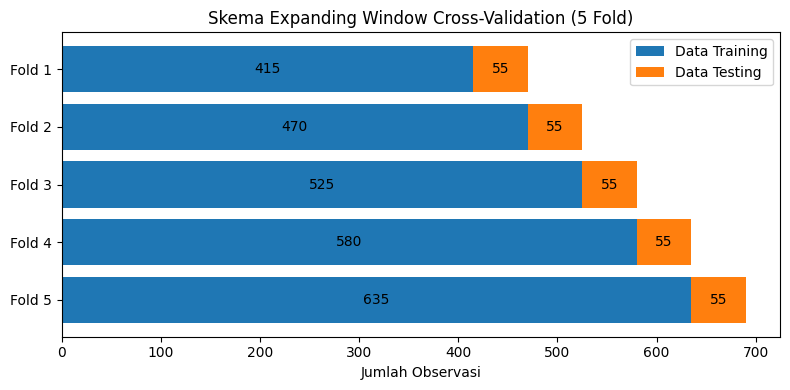

In [ ]:
import matplotlib.pyplot as plt

# Ukuran data tiap fold
train_sizes = [415, 470, 525, 580, 635]
test_sizes = [55, 55, 55, 55, 55]

fold_labels = [f'Fold {i}' for i in range(1, 6)]

fig, ax = plt.subplots(figsize=(8, 4))

# Warna konsisten
train_color = 'tab:blue'
test_color = 'tab:orange'

for i in range(len(fold_labels)):

    # Data training
    ax.barh(
        fold_labels[i],
        train_sizes[i],
        color=train_color,
        label='Data Training' if i == 0 else ""
    )

    # Data testing
    ax.barh(
        fold_labels[i],
        test_sizes[i],
        left=train_sizes[i],
        color=test_color,
        label='Data Testing' if i == 0 else ""
    )

    # Label jumlah observasi
    ax.text(
        train_sizes[i] / 2,
        i,
        str(train_sizes[i]),
        ha='center',
        va='center',
        color='black'
    )

    ax.text(
        train_sizes[i] + test_sizes[i] / 2,
        i,
        str(test_sizes[i]),
        ha='center',
        va='center',
        color='black'
    )

ax.set_xlabel('Jumlah Observasi')
ax.set_title('Skema Expanding Window Cross-Validation (5 Fold)')
ax.legend()
ax.invert_yaxis()  # Fold 1 di atas

plt.tight_layout()
plt.show()

## 6. Cross-Validation ANN (Expanding Window)

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('='*55)
print('  CROSS-VALIDATION ANN — EXPANDING WINDOW')
print('='*55)

ann_train_fold_metrics = []
ann_test_fold_metrics  = [] # Renamed from ann_fold_metrics for clarity
ann_all_actual   = []
ann_all_pred     = []
ann_fold_history = []

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}] ({train_end} data)')
    print(f'   Test : [{train_end}:{test_end}] ({test_end-train_end} data)')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi (fit HANYA pada training)
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Build & train ANN
    tf.random.set_seed(42)
    model = build_ann_model(M, q, LR)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr_s, y_tr_s, epochs=200, batch_size=16,
                     validation_split=0.15, callbacks=cb, verbose=0)
    ann_fold_history.append(hist.history)

    # TRAINING PERFORMANCE
    y_train_pred_s = model.predict(X_tr_s, verbose=0)
    y_train_pred = sc_y.inverse_transform(y_train_pred_s).flatten()
    y_train_true = y_train.flatten()

    train_metrics = evaluate(y_train_true, y_train_pred)
    ann_train_fold_metrics.append(train_metrics) # Store training metrics

    # TESTING PERFORMANCE
    y_test_pred_s = model.predict(X_te_s, verbose=0)
    y_test_pred = sc_y.inverse_transform(y_test_pred_s).flatten()
    y_test_true = y_test.flatten()

    test_metrics = evaluate(y_test_true, y_test_pred)
    ann_test_fold_metrics.append(test_metrics) # Store testing metrics
    ann_all_actual.extend(y_test_true)
    ann_all_pred.extend(y_test_pred)

    print("\nTraining:")
    print(f"RMSE={train_metrics['RMSE']:.4f} "
          f"MAE={train_metrics['MAE']:.4f} "
          f"MAPE={train_metrics['MAPE']:.2f}% "
          f"R²={train_metrics['R2']:.4f}")

    print("\nTesting:")
    print(f"RMSE={test_metrics['RMSE']:.4f} "
          f"MAE={test_metrics['MAE']:.4f} "
          f"MAPE={test_metrics['MAPE']:.2f}% "
          f"R²={test_metrics['R2']:.4f}")

# Rata-rata metrik training
ann_train_mean = {k: np.mean([m[k] for m in ann_train_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
ann_train_std  = {k: np.std ([m[k] for m in ann_train_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

# Rata-rata metrik testing
ann_test_mean = {k: np.mean([m[k] for m in ann_test_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']} # Renamed from ann_mean
ann_test_std  = {k: np.std ([m[k] for m in ann_test_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}  # Renamed from ann_std

print('\n' + '='*55)
print('  RATA-RATA CV ANN (TRAINING)')
print('='*55)

for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_train_mean[k]:.4f} \u00b1 {ann_train_std[k]:.4f}{unit}')

print('='*55)

print('\n' + '='*55)
print('  RATA-RATA CV ANN (TESTING)')
print('='*55)

for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' \u00b5g/m\u00b3' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {ann_test_mean[k]:.4f} \u00b1 {ann_test_std[k]:.4f}{unit}')

print('='*55)


  CROSS-VALIDATION ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:415] (415 data)
   Test : [415:470] (55 data)

Training:
RMSE=7.0829 MAE=5.0734 MAPE=10.11% R²=0.8729

Testing:
RMSE=7.4139 MAE=5.9272 MAPE=10.59% R²=0.6932

── Fold 2/5 ──
   Train: [0:470] (470 data)
   Test : [470:525] (55 data)

Training:
RMSE=6.9588 MAE=5.0293 MAPE=10.09% R²=0.8712

Testing:
RMSE=9.3877 MAE=6.9031 MAPE=8.35% R²=0.6183

── Fold 3/5 ──
   Train: [0:525] (525 data)
   Test : [525:580] (55 data)

Training:
RMSE=7.6024 MAE=5.6403 MAPE=10.51% R²=0.8471

Testing:
RMSE=12.6029 MAE=10.6585 MAPE=11.61% R²=0.3769

── Fold 4/5 ──
   Train: [0:580] (580 data)
   Test : [580:635] (55 data)

Training:
RMSE=7.6821 MAE=5.5653 MAPE=10.17% R²=0.8521

Testing:
RMSE=8.4777 MAE=6.9605 MAPE=7.86% R²=0.4681

── Fold 5/5 ──
   Train: [0:635] (635 data)
   Test : [635:690] (55 data)

Training:
RMSE=7.5330 MAE=5.4743 MAPE=9.43% R²=0.8559

Testing:
RMSE=9.6924 MAE=8.4122 MAPE=13.34% R²=0.7021

  RATA-RATA CV ANN (TRAINING

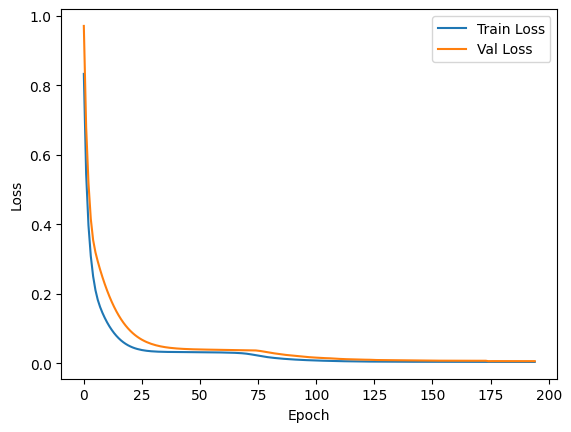

In [ ]:
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 7. PSO-ANN: Implementasi PSO
PSO mengoptimasi **semua bobot dan bias** jaringan ANN sebagai satu vektor partikel.

Pembaruan kecepatan (Persamaan 4 analog PSO):
$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (p_i - x_i^t) + c_2 r_2 (g - x_i^t)$$

Pembaruan posisi:
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$

In [ ]:
def get_weight_count(input_dim, hidden_neurons):
    """Hitung total bobot + bias jaringan M→q→1."""
    return (input_dim * hidden_neurons + hidden_neurons +
            hidden_neurons * 1 + 1)


def set_weights_from_vector(model, vec):
    """Terapkan vektor partikel sebagai bobot model."""
    shapes = [w.shape for w in model.get_weights()]
    weights = []
    idx = 0
    for shape in shapes:
        size = np.prod(shape)
        weights.append(vec[idx:idx+size].reshape(shape))
        idx += size
    model.set_weights(weights)


def fitness(vec, model, X_tr, y_tr):
    """Fungsi fitness = MSE pada data training (Persamaan 2)."""
    set_weights_from_vector(model, vec)
    y_pred = model.predict(X_tr, verbose=0).flatten()
    return np.mean((y_tr.flatten() - y_pred) ** 2)


def pso_optimize(model, X_tr, y_tr,
                 n_particles=30, n_iter=50,
                 w=0.7, c1=1.5, c2=1.5, v_max=0.5,
                 verbose_every=10):
    """
    Optimasi bobot ANN menggunakan PSO.
    Returns: bobot terbaik (vektor), history fitness global best.
    """
    n_dim = get_weight_count(X_tr.shape[1],
                             model.get_layer('hidden').units)

    # Inisialisasi posisi & kecepatan partikel
    pos = np.random.uniform(-1, 1, (n_particles, n_dim))
    vel = np.random.uniform(-v_max, v_max, (n_particles, n_dim))

    # Evaluasi fitness awal
    fit  = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])
    pbest     = pos.copy()
    pbest_fit = fit.copy()

    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    history_gbest = [gbest_fit]

    for it in range(n_iter):
        r1 = np.random.rand(n_particles, n_dim)
        r2 = np.random.rand(n_particles, n_dim)

        # Update kecepatan (Persamaan PSO)
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        vel = np.clip(vel, -v_max, v_max)

        # Update posisi
        pos = pos + vel

        # Evaluasi fitness
        fit = np.array([fitness(pos[i], model, X_tr, y_tr) for i in range(n_particles)])

        # Update personal best
        better = fit < pbest_fit
        pbest[better]     = pos[better]
        pbest_fit[better] = fit[better]

        # Update global best
        if pbest_fit.min() < gbest_fit:
            gbest_idx = np.argmin(pbest_fit)
            gbest     = pbest[gbest_idx].copy()
            gbest_fit = pbest_fit[gbest_idx]

        history_gbest.append(gbest_fit)

        if verbose_every and (it+1) % verbose_every == 0:
            print(f'     iter {it+1:3d}/{n_iter} | best MSE = {gbest_fit:.6f}')

    return gbest, history_gbest


print('Fungsi PSO siap ✅')
print(f'Dimensi vektor partikel (bobot+bias): {get_weight_count(M, q)}')

Fungsi PSO siap ✅
Dimensi vektor partikel (bobot+bias): 89


## 8. Cross-Validation PSO-ANN (Expanding Window)


In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

pso_fold_metrics  = []
pso_all_actual    = []
pso_all_pred      = []
pso_fold_gbest    = []   # konvergensi PSO per fold

for fold_idx, (train_end, test_end) in enumerate(folds):
    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')
    print(f'   Train: [0:{train_end}]  Test: [{train_end}:{test_end}]')

    # Split
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # Normalisasi
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()
    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)
    X_te_s = sc_X.transform(X_test)

    # Fase 1: PSO menemukan bobot awal terbaik
    print('   [Fase 1] PSO mencari bobot optimal...')
    np.random.seed(42)
    tf.random.set_seed(42)
    pso_model = build_ann_model(M, q, LR)

    best_weights, gbest_hist = pso_optimize(
        pso_model, X_tr_s, y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO, c1=C1, c2=C2, v_max=V_MAX,
        verbose_every=10
    )
    pso_fold_gbest.append(gbest_hist)

    # Terapkan bobot PSO ke model
    set_weights_from_vector(pso_model, best_weights)

    # Fase 2: Fine-tune dengan backpropagation
    print('   [Fase 2] Fine-tuning dengan backpropagation...')
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=8, min_lr=1e-6, verbose=0)
    ]
    pso_model.fit(X_tr_s, y_tr_s, epochs=100, batch_size=16,
                  validation_split=0.15, callbacks=cb, verbose=0)

    # Prediksi
    y_pred_s = pso_model.predict(X_te_s, verbose=0)
    y_pred   = sc_y.inverse_transform(y_pred_s).flatten()
    y_true   = y_test.flatten()

    metrics = evaluate(y_true, y_pred)
    pso_fold_metrics.append(metrics)
    pso_all_actual.extend(y_true)
    pso_all_pred.extend(y_pred)

    print(f'   RMSE={metrics["RMSE"]:.4f}  MAE={metrics["MAE"]:.4f}  '
          f'MAPE={metrics["MAPE"]:.2f}%  R²={metrics["R2"]:.4f}')

# Rata-rata metrik
pso_mean = {k: np.mean([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}
pso_std  = {k: np.std ([m[k] for m in pso_fold_metrics]) for k in ['RMSE','MAE','MAPE','R2']}

print('\n' + '='*55)
print('  RATA-RATA CV PSO-ANN')
print('='*55)
for k in ['RMSE','MAE','MAPE','R2']:
    unit = ' µg/m³' if k in ['RMSE','MAE'] else (' %' if k=='MAPE' else '')
    print(f'  {k:5s}: {pso_mean[k]:.4f} ± {pso_std[k]:.4f}{unit}')
print('='*55)

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   Train: [0:415]  Test: [415:470]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.014276
     iter  20/50 | best MSE = 0.011137
     iter  30/50 | best MSE = 0.006596
     iter  40/50 | best MSE = 0.005745
     iter  50/50 | best MSE = 0.005284
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=7.7547  MAE=6.0192  MAPE=10.46%  R²=0.6644

── Fold 2/5 ──
   Train: [0:470]  Test: [470:525]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.013619
     iter  20/50 | best MSE = 0.006484
     iter  30/50 | best MSE = 0.005808
     iter  40/50 | best MSE = 0.005229
     iter  50/50 | best MSE = 0.004869
   [Fase 2] Fine-tuning dengan backpropagation...
   RMSE=8.5594  MAE=6.3001  MAPE=7.71%  R²=0.6827

── Fold 3/5 ──
   Train: [0:525]  Test: [525:580]
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.013237
     iter  20/50 | best MSE = 0.006238
     iter

# 9. Perbandingan Hasil ANN vs PSO-ANN

In [ ]:
import pandas as pd

# Tabel perbandingan per fold
rows = []
for i, (am, pm) in enumerate(zip(ann_test_fold_metrics, pso_fold_metrics)): # Changed ann_fold_metrics to ann_test_fold_metrics
    rows.append({
        'Fold'         : i+1,
        'ANN RMSE'     : round(am['RMSE'], 4),
        'PSO-ANN RMSE' : round(pm['RMSE'], 4),
        'ANN MAE'      : round(am['MAE'],  4),
        'PSO-ANN MAE'  : round(pm['MAE'],  4),
        'ANN R²'       : round(am['R2'],   4),
        'PSO-ANN R²'   : round(pm['R2'],   4),
    })

rows.append({
    'Fold'         : 'Rata-rata',
    'ANN RMSE'     : round(ann_test_mean['RMSE'], 4), # Changed ann_mean to ann_test_mean
    'PSO-ANN RMSE' : round(pso_mean['RMSE'], 4),
    'ANN MAE'      : round(ann_test_mean['MAE'],  4),  # Changed ann_mean to ann_test_mean
    'PSO-ANN MAE'  : round(pso_mean['MAE'],  4),
    'ANN R²'       : round(ann_test_mean['R2'],   4),   # Changed ann_mean to ann_test_mean
    'PSO-ANN R²'   : round(pso_mean['R2'],   4),
})

df_result = pd.DataFrame(rows).set_index('Fold')
print('\nPerbandingan Metrik ANN vs PSO-ANN (Expanding Window CV):')
display(df_result)


Perbandingan Metrik ANN vs PSO-ANN (Expanding Window CV):


,ANN RMSE,PSO-ANN RMSE,ANN MAE,PSO-ANN MAE,ANN R²,PSO-ANN R²
Fold,,,,,,
1,7.4139,7.7547,5.9272,6.0192,0.6932,0.6644
2,9.3877,8.5594,6.9031,6.3001,0.6183,0.6827
3,12.6029,11.8515,10.6585,10.1454,0.3769,0.4490
4,8.4777,6.9158,6.9605,5.4173,0.4681,0.6461
5,9.6924,8.8444,8.4122,7.5081,0.7021,0.7520
Rata-rata,9.5149,8.7852,7.7723,7.0780,0.5717,0.6388


# 10. Visualisasi

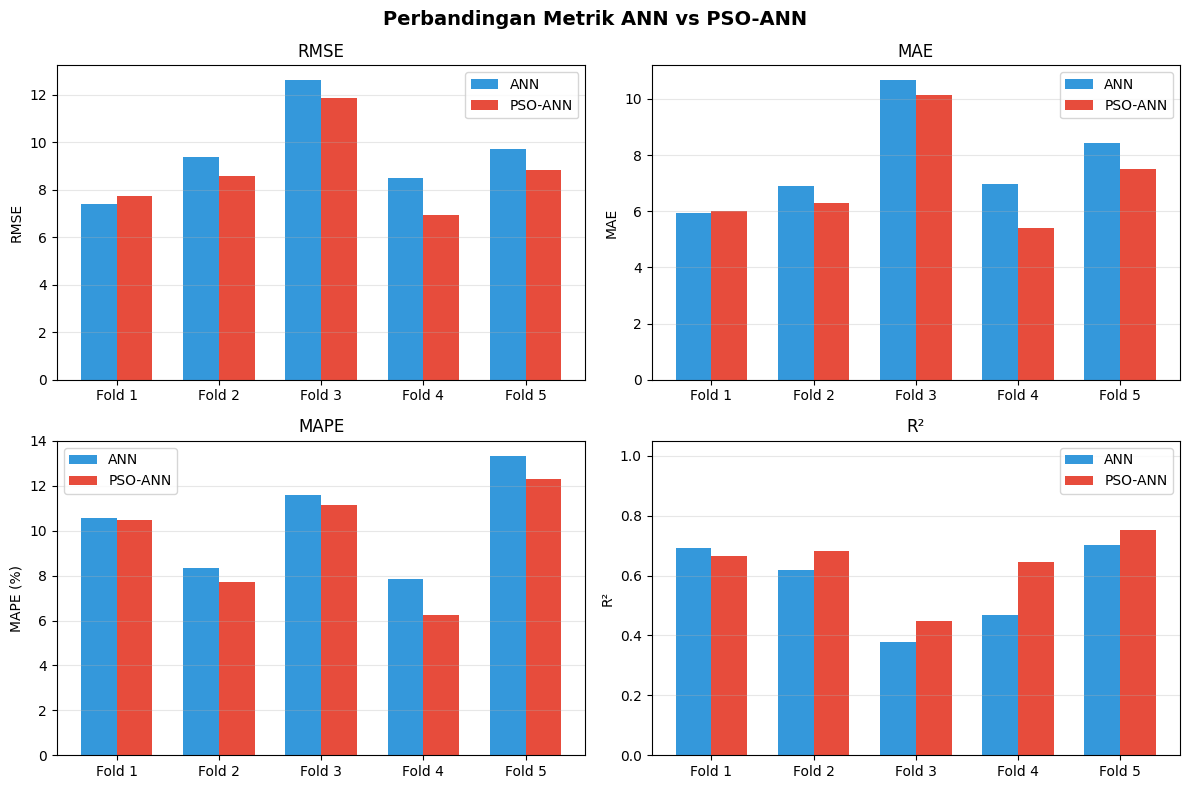

In [ ]:
import matplotlib.pyplot as plt

# PLOT METRIK PER FOLD (4 PANEL)
fig, axes = plt.subplots(2, 2, figsize=(12,8))

fig.suptitle(
    'Perbandingan Metrik ANN vs PSO-ANN',
    fontsize=14,
    fontweight='bold'
)

folds_label = [f'Fold {i+1}' for i in range(len(folds))]
x = np.arange(len(folds_label))
w = 0.35

# Extract metrics for plotting
ann_rmse = [m['RMSE'] for m in ann_test_fold_metrics]
pso_rmse = [m['RMSE'] for m in pso_fold_metrics]
ann_mae = [m['MAE'] for m in ann_test_fold_metrics]
pso_mae = [m['MAE'] for m in pso_fold_metrics]
ann_mape = [m['MAPE'] for m in ann_test_fold_metrics]
pso_mape = [m['MAPE'] for m in pso_fold_metrics]
ann_r2 = [m['R2'] for m in ann_test_fold_metrics]
pso_r2 = [m['R2'] for m in pso_fold_metrics]

# RMSE
axes[0,0].bar(
    x - w/2, ann_rmse, w,
    label='ANN',
    color='#3498db'
)

axes[0,0].bar(
    x + w/2, pso_rmse, w,
    label='PSO-ANN',
    color='#e74c3c'
)

axes[0,0].set_title('RMSE')
axes[0,0].set_ylabel('RMSE')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(folds_label)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# MAE
axes[0,1].bar(
    x - w/2, ann_mae, w,
    label='ANN',
    color='#3498db'
)

axes[0,1].bar(
    x + w/2, pso_mae, w,
    label='PSO-ANN',
    color='#e74c3c'
)

axes[0,1].set_title('MAE')
axes[0,1].set_ylabel('MAE')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(folds_label)
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)

# MAPE
axes[1,0].bar(
    x - w/2, ann_mape, w,
    label='ANN',
    color='#3498db'
)

axes[1,0].bar(
    x + w/2, pso_mape, w,
    label='PSO-ANN',
    color='#e74c3c'
)

axes[1,0].set_title('MAPE')
axes[1,0].set_ylabel('MAPE (%)')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(folds_label)
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# R²
axes[1,1].bar(
    x - w/2, ann_r2, w,
    label='ANN',
    color='#3498db'
)

axes[1,1].bar(
    x + w/2, pso_r2, w,
    label='PSO-ANN',
    color='#e74c3c'
)

axes[1,1].set_title('R²')
axes[1,1].set_ylabel('R²')
axes[1,1].set_ylim(0, 1.05)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(folds_label)
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig('hasil_CV_ANN_PSOANN.png')
plt.show()

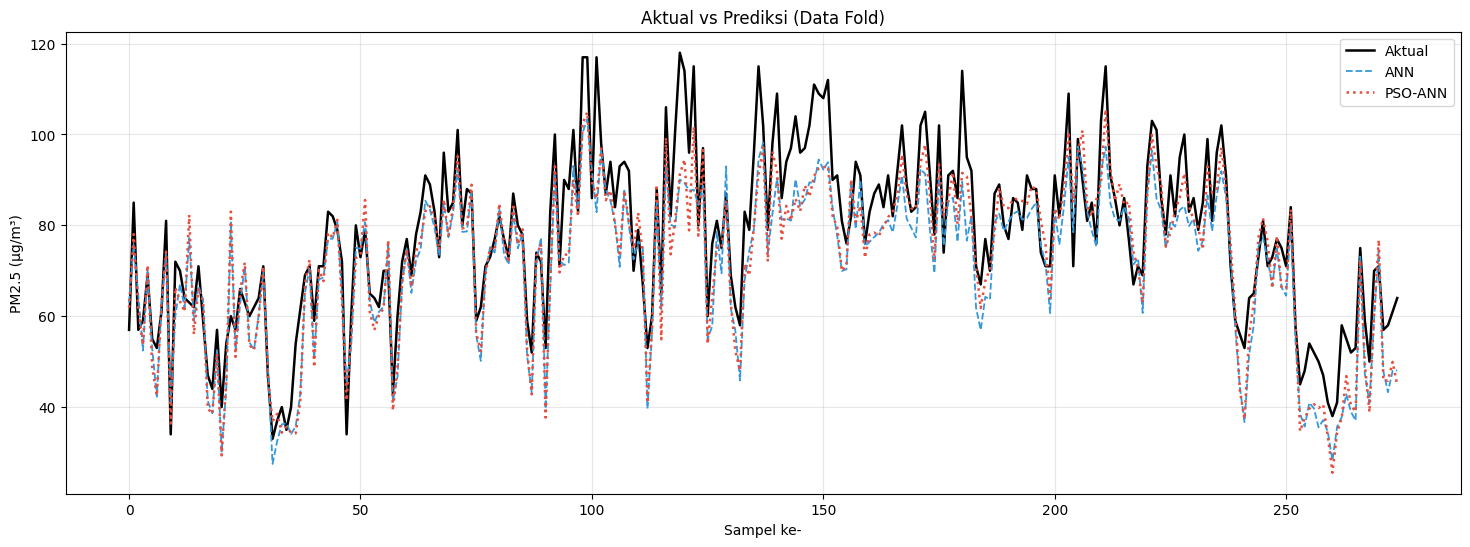

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(
    ann_all_actual,
    color='black',
    lw=1.8,
    label='Aktual'
)

plt.plot(
    ann_all_pred,
    '--',
    color='#3498db',
    lw=1.3,
    label='ANN'
)

plt.plot(
    pso_all_pred,
    ':',
    color='#e74c3c',
    lw=1.8,
    label='PSO-ANN'
)

plt.xlabel('Sampel ke-')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Aktual vs Prediksi (Data Fold)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

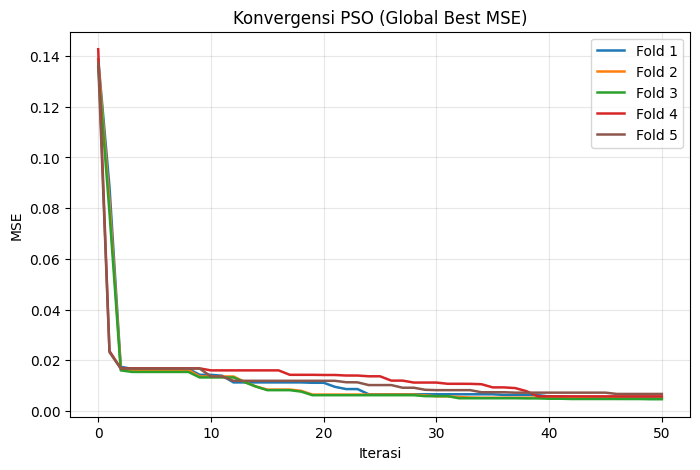

In [ ]:
# 6. KONVERGENSI PSO
plt.figure(figsize=(8,5))

colors_fold = plt.cm.tab10(
    np.linspace(0, 0.5, len(pso_fold_gbest))
)

for i, gh in enumerate(pso_fold_gbest):
    plt.plot(gh,
             lw=1.8,
             color=colors_fold[i],
             label=f'Fold {i+1}')

plt.xlabel('Iterasi')
plt.ylabel('MSE')
plt.title('Konvergensi PSO (Global Best MSE)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# 11. Ringkasan Akhir

In [ ]:
print('\n' + '='*60)
print('  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW')
print('  Stasiun Bundaran HI — Prediksi PM2.5')
print('='*60)
print(f'  Arsitektur : {M} → {q} → 1  (input → hidden → output)')
print(f'  Peubah input: {FEATURES}')
print(f'  Jumlah fold : {N_FOLDS}')
print()
header = f'{"Metrik":8s}  {"ANN":>12s}  {"PSO-ANN":>12s}  {"Selisih":>10s}'
print(header)
print('-'*50)
for k in ['RMSE','MAE','MAPE','R2']:
    diff  = pso_mean[k] - ann_test_mean[k]
    better = '↓ lebih baik' if (k != 'R2' and diff < 0) else ('↑ lebih baik' if (k == 'R2' and diff > 0) else '─')
    print(f'  {k:6s}  {ann_test_mean[k]:10.4f}    {pso_mean[k]:10.4f}   {diff:+.4f}  {better}')
print('='*60)


  RINGKASAN HASIL CROSS-VALIDATION EXPANDING WINDOW
  Stasiun Bundaran HI — Prediksi PM2.5
  Arsitektur : 9 → 8 → 1  (input → hidden → output)
  Peubah input: ['PM10', 'SO2', 'PM25_lag1', 'PM25_lag2', 'PM25_lag3', 'PM25_lag4', 'PM25_lag5', 'PM25_lag6', 'PM25_lag7']
  Jumlah fold : 5

Metrik             ANN       PSO-ANN     Selisih
--------------------------------------------------
  RMSE        9.5149        8.7852   -0.7298  ↓ lebih baik
  MAE         7.7723        7.0780   -0.6943  ↓ lebih baik
  MAPE       10.3496        9.5793   -0.7702  ↓ lebih baik
  R2          0.5717        0.6388   +0.0671  ↑ lebih baik


# Cek Overfit PSO

In [ ]:
print('='*55)
print('  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW')
print('='*55)

# LIST MENYIMPAN METRIK
train_metrics_list = []
test_metrics_list  = []

pso_all_actual = []
pso_all_pred   = []

for fold_idx, (train_end, test_end) in enumerate(folds):

    print(f'\n── Fold {fold_idx+1}/{len(folds)} ──')

    # SPLIT DATA
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]

    X_test  = X_all[train_end:test_end]
    y_test  = y_all[train_end:test_end]

    # NORMALISASI
    sc_X = MinMaxScaler()
    sc_y = MinMaxScaler()

    X_tr_s = sc_X.fit_transform(X_train)
    y_tr_s = sc_y.fit_transform(y_train)

    X_te_s = sc_X.transform(X_test)

    # BUILD MODEL
    np.random.seed(42)
    tf.random.set_seed(42)

    pso_model = build_ann_model(M, q, LR)

    # FASE 1 — PSO
    print('   [Fase 1] PSO mencari bobot optimal...')

    best_weights, gbest_hist = pso_optimize(
        pso_model,
        X_tr_s,
        y_tr_s,
        n_particles=N_PARTICLES,
        n_iter=PSO_ITER,
        w=W_PSO,
        c1=C1,
        c2=C2,
        v_max=V_MAX,
        verbose_every=10
    )

    set_weights_from_vector(pso_model, best_weights)

    # FASE 2 — BACKPROPAGATION
    print('   [Fase 2] Fine-tuning backpropagation...')

    cb = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=0
        ),

        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=0
        )
    ]

    pso_model.fit(
        X_tr_s,
        y_tr_s,
        epochs=100,
        batch_size=16,
        validation_split=0.15,
        callbacks=cb,
        verbose=0
    )

    # PREDIKSI TRAIN
    y_train_pred_s = pso_model.predict(X_tr_s, verbose=0)

    y_train_pred = sc_y.inverse_transform(
        y_train_pred_s
    ).flatten()

    y_train_true = y_train.flatten()

    train_metrics = evaluate(
        y_train_true,
        y_train_pred
    )

    train_metrics_list.append(train_metrics)

    # PREDIKSI TEST
    y_test_pred_s = pso_model.predict(X_te_s, verbose=0)

    y_test_pred = sc_y.inverse_transform(
        y_test_pred_s
    ).flatten()

    y_test_true = y_test.flatten()

    test_metrics = evaluate(
        y_test_true,
        y_test_pred
    )

    test_metrics_list.append(test_metrics)

    # Simpan seluruh hasil test
    pso_all_actual.extend(y_test_true)
    pso_all_pred.extend(y_test_pred)

    # PRINT METRIK
    print('\n   TRAIN')
    print(f'   RMSE={train_metrics["RMSE"]:.4f}')
    print(f'   MAE ={train_metrics["MAE"]:.4f}')
    print(f'   MAPE={train_metrics["MAPE"]:.2f}%')
    print(f'   R²  ={train_metrics["R2"]:.4f}')

    print('\n   TEST')
    print(f'   RMSE={test_metrics["RMSE"]:.4f}')
    print(f'   MAE ={test_metrics["MAE"]:.4f}')
    print(f'   MAPE={test_metrics["MAPE"]:.2f}%')
    print(f'   R²  ={test_metrics["R2"]:.4f}')

# RATA-RATA SEMUA FOLD
print('\n' + '='*55)
print('RATA-RATA TRAIN')
print('='*55)

for metric in ['RMSE','MAE','MAPE','R2']:

    mean_val = np.mean([
        m[metric] for m in train_metrics_list
    ])

    print(f'{metric}: {mean_val:.4f}')

print('\n' + '='*55)
print('RATA-RATA TEST')
print('='*55)

for metric in ['RMSE','MAE','MAPE','R2']:

    mean_val = np.mean([
        m[metric] for m in test_metrics_list
    ])

    print(f'{metric}: {mean_val:.4f}')

  CROSS-VALIDATION PSO-ANN — EXPANDING WINDOW

── Fold 1/5 ──
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.014276
     iter  20/50 | best MSE = 0.011137
     iter  30/50 | best MSE = 0.006596
     iter  40/50 | best MSE = 0.005745
     iter  50/50 | best MSE = 0.005284
   [Fase 2] Fine-tuning backpropagation...

   TRAIN
   RMSE=7.0482
   MAE =4.8745
   MAPE=10.19%
   R²  =0.8741

   TEST
   RMSE=7.7547
   MAE =6.0192
   MAPE=10.46%
   R²  =0.6644

── Fold 2/5 ──
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 0.013619
     iter  20/50 | best MSE = 0.006484
     iter  30/50 | best MSE = 0.005808
     iter  40/50 | best MSE = 0.005229
     iter  50/50 | best MSE = 0.004869
   [Fase 2] Fine-tuning backpropagation...

   TRAIN
   RMSE=6.9973
   MAE =4.9722
   MAPE=10.07%
   R²  =0.8698

   TEST
   RMSE=8.5594
   MAE =6.3001
   MAPE=7.71%
   R²  =0.6827

── Fold 3/5 ──
   [Fase 1] PSO mencari bobot optimal...
     iter  10/50 | best MSE = 

# Peramalan

In [ ]:
# FORECAST 14 HARI KE DEPAN — PSO-ANN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# AMBIL MODEL TERAKHIR
# pso_model berasal dari hasil training PSO-ANN sebelumnya

# AMBIL 7 DATA PM2.5 TERAKHIR
last_pm25 = df['PM25'].values[-7:].tolist()

# Gunakan nilai terakhir PM10 & SO2
PM10_value = df['PM10'].iloc[-1]
SO2_value  = df['SO2'].iloc[-1]

# LIST HASIL FORECAST
forecast_14days = []

# FORECAST RECURSIVE 14 HARI
for step in range(14):

    # Susun fitur sesuai training model
    input_features = [
        PM10_value,
        SO2_value,
        *last_pm25[-7:]
    ]

    # Ubah ke array 2D
    X_new = np.array(input_features).reshape(1, -1)

    # Scaling input
    X_new_scaled = sc_X.transform(X_new)

    # Prediksi dengan PSO-ANN
    y_pred_scaled = pso_model.predict(X_new_scaled, verbose=0)

    # Kembalikan ke skala asli
    y_pred = sc_y.inverse_transform(y_pred_scaled)[0,0]

    # Hindari negatif
    y_pred = max(0, y_pred)

    # Simpan hasil forecast
    forecast_14days.append(y_pred)

    # Update lag untuk prediksi berikutnya
    last_pm25.append(y_pred)

# MEMBUAT TANGGAL FORECAST

last_date = df['Tanggal'].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=14,
    freq='D'
)

# TABEL HASIL FORECAST
forecast_df = pd.DataFrame({
    'Tanggal': future_dates,
    'Forecast_PM25': np.round(forecast_14days, 2)
})
print('\nFORECAST PM2.5 14 HARI KE DEPAN')
print(forecast_df.to_string(index=False))


FORECAST PM2.5 14 HARI KE DEPAN
   Tanggal  Forecast_PM25
2025-12-01      84.209999
2025-12-02      80.919998
2025-12-03      90.570000
2025-12-04      78.930000
2025-12-05      98.209999
2025-12-06      88.970001
2025-12-07      93.150002
2025-12-08      93.330002
2025-12-09      87.730003
2025-12-10      95.889999
2025-12-11      87.389999
2025-12-12      95.540001
2025-12-13      91.879997
2025-12-14      92.489998


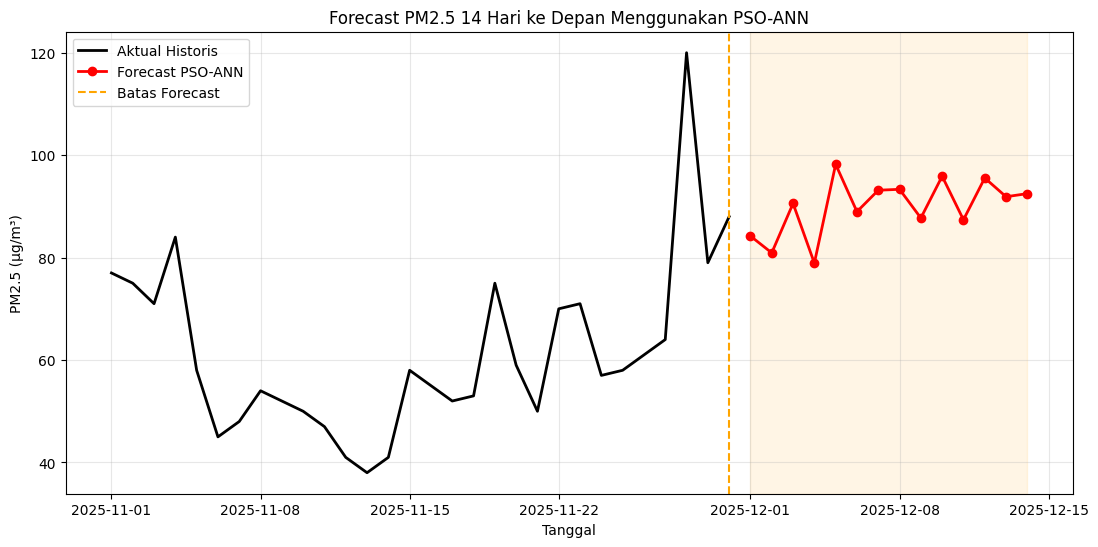

In [ ]:
# VISUALISASI
hist_days = 30

hist_dates = df['Tanggal'].iloc[-hist_days:]
hist_values = df['PM25'].iloc[-hist_days:]

plt.figure(figsize=(13,6))

# Data historis
plt.plot(
    hist_dates,
    hist_values,
    linewidth=2,
    color='black',
    label='Aktual Historis'
)

# Forecast
plt.plot(
    future_dates,
    forecast_14days,
    marker='o',
    linewidth=2,
    color='red',
    label='Forecast PSO-ANN'
)

# Garis batas forecast
plt.axvline(
    x=last_date,
    linestyle='--',
    color='orange',
    label='Batas Forecast'
)

# Arsiran area forecast
plt.axvspan(
    future_dates[0],
    future_dates[-1],
    color='orange',
    alpha=0.1
)

plt.title('Forecast PM2.5 14 Hari ke Depan Menggunakan PSO-ANN')
plt.xlabel('Tanggal')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()